# Classical Machine Learning: Part 3

## Decision Trees (Using Diabetes Prediction Dataset from Kaggle)

A **decision tree** is a supervised machine learning model used for classification and regression tasks. It recursively splits the input space into regions based on feature values and makes a decision based on the majority class or average value in that region. Each internal node represents a decision based on a feature, and each leaf node represents an output.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df=pd.read_csv('diabetes_prediction_dataset.csv')

print('\nData Information:')
print(df.info())
print('\nFirst 5 records:')
print(df.head())
print('\nSummary Statistics:')
print(df.describe())


Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB
None

First 5 records:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             

In [3]:
X=df.drop('diabetes',axis=1)
y=df['diabetes']

X=X.drop('gender',axis=1)
X=X.drop('smoking_history',axis=1)

print('\nFeatures shape:',X.shape)
print('Target shape:',y.shape)


 (100000, 6)pe:
Target shape: (100000,)


In [4]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.3,random_state=42)

print('\nTraining set shapes:')
print('X_train: ',X_train.shape)
print('y_train: ',y_train.shape)
print('\nTesting set shapes:')
print('X_test: ',X_test.shape)
print('y_test: ',y_test.shape)


Training set shapes:
X_train:  (70000, 6)
y_train:  (70000,)

Testing set shapes:
X_test:  (30000, 6)
y_test:  (30000,)


In [5]:
model=DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print('\nModel has been trained')

model=DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)


Model has been trained


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

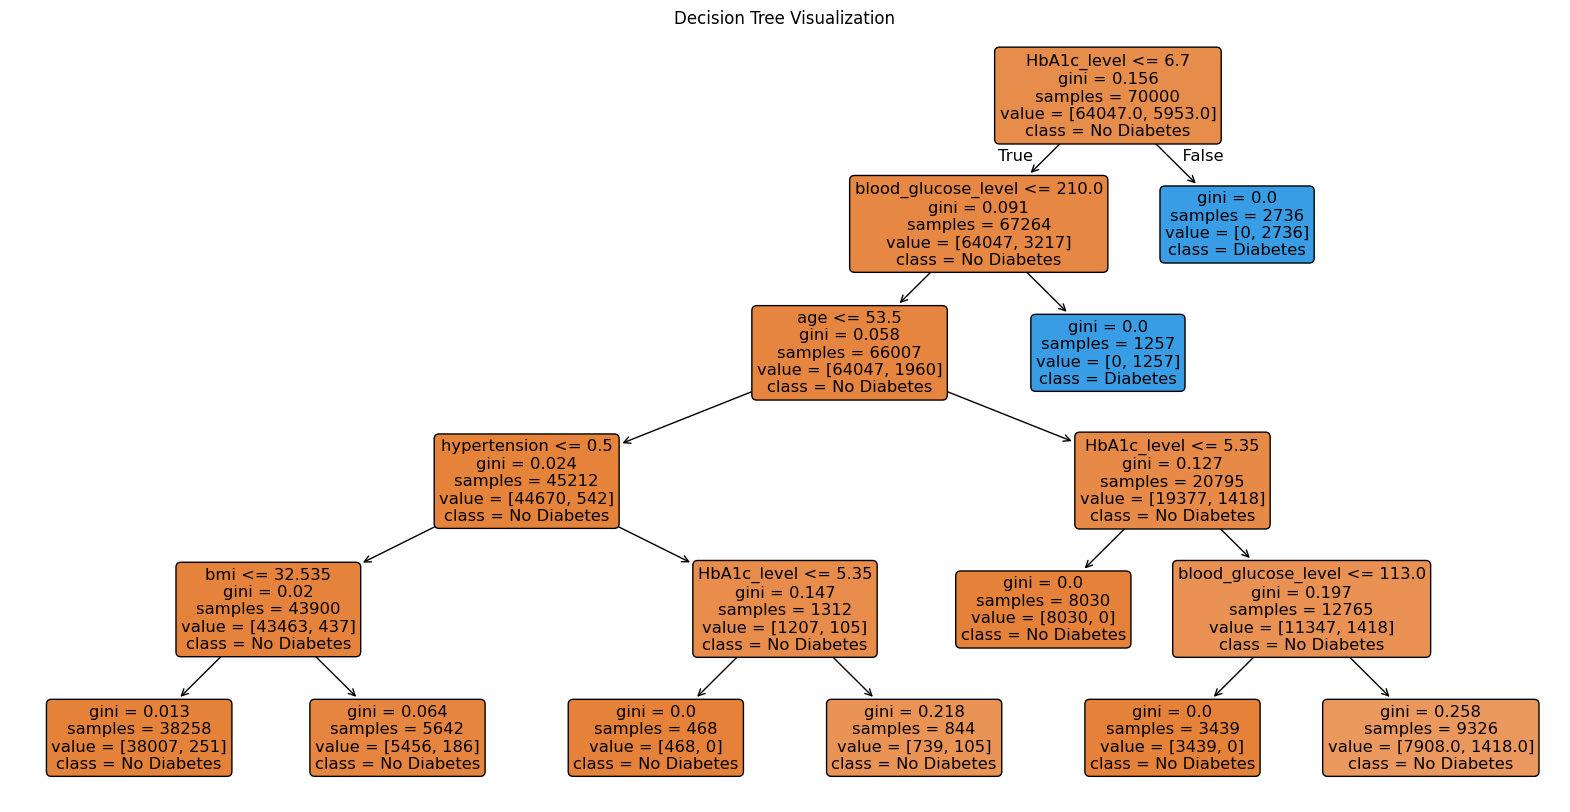

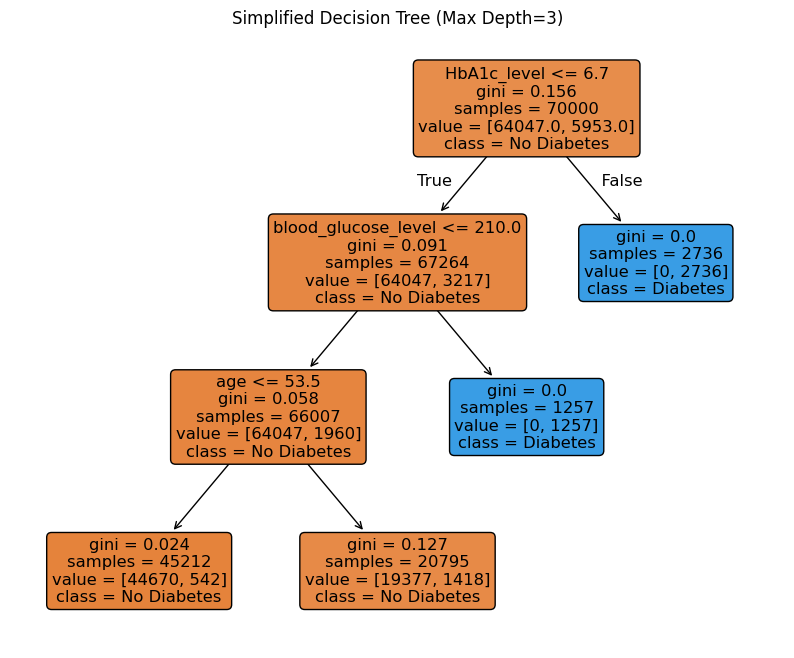

In [6]:
plt.figure(figsize=(20,10))
plot_tree(model,
          filled=True,
          feature_names=X.columns,
          class_names=['No Diabetes','Diabetes'],
          rounded=True)

plt.title('Decision Tree Visualization')
plt.savefig('diabetes_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

max_depth=3
model_simple=DecisionTreeClassifier(max_depth=max_depth, random_state=42)
model_simple.fit(X_train,y_train)
plt.figure(figsize=(10,8))
plot_tree(model_simple,
          filled=True,
          feature_names=X.columns,
          class_names=['No Diabetes','Diabetes'],
          rounded=True)
plt.title(f'Simplified Decision Tree (Max Depth={max_depth})')
plt.show()

## Evaluating Decision Tree Performance and Avoiding Overfitting

In [7]:
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)

predictions=model.predict(X_test)

accuracy=accuracy_score(y_test, predictions)
print(f'Initial Model Accuracy: {accuracy:.4f}')

cm=confusion_matrix(y_test, predictions)
print('\nConfusion Matrix')
print(cm)

print('\nClassification Report:')
print(classification_report(y_test,predictions))

Initial Model Accuracy: 0.9543

Confusion Matrix
[[26764   689]
 [  683  1864]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     27453
           1       0.73      0.73      0.73      2547

    accuracy                           0.95     30000
   macro avg       0.85      0.85      0.85     30000
weighted avg       0.95      0.95      0.95     30000



<Figure size 800x600 with 0 Axes>

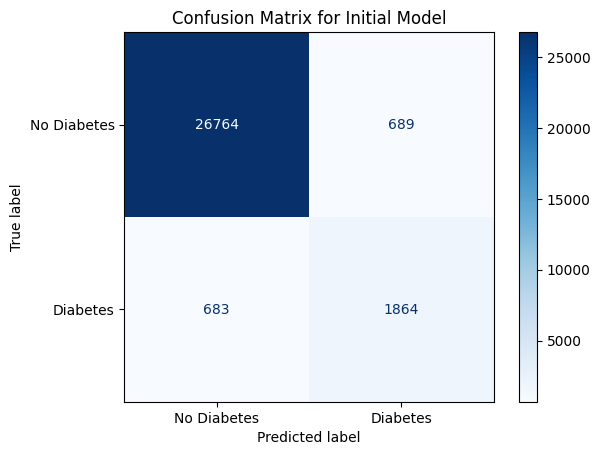

In [8]:
plt.figure(figsize=(8,6))
cmd=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes','Diabetes'])
cmd.plot(cmap='Blues')
plt.title('Confusion Matrix for Initial Model')
plt.grid(False)
plt.show()

tn,fn,fp,tp=cm.ravel()

In [9]:
print(f'Depth of the original tree: {model.get_depth()}')
print(f'No. of leaves in the original tree: {model.get_n_leaves()}')

pruned_model=DecisionTreeClassifier(min_samples_leaf=1270, random_state=46)
pruned_model.fit(X_train, y_train)
pruned_predictions=pruned_model.predict(X_test)

pruned_accuracy=accuracy_score(y_test, pruned_predictions)
print(f'\nPruned Model Accuracy: {pruned_accuracy:.2f}')

pruned_cm=confusion_matrix(y_test, pruned_predictions)
print('\nConfusion Matrix for Pruned Model')

print('\nClassification Report for Pruned Model:')
print(classification_report(y_test,pruned_predictions))

max_depths=range(1,10)
train_scores=[]
test_scores=[]

for depth in max_depths:
    model=DecisionTreeClassifier(max_depth=depth, random_state=46)
    model.fit(X_train, y_train)
    
    train_pred=model.predict(X_train)
    test_pred=model.predict(X_test)

    train_scores.append(accuracy_score(y_train,train_pred))
    test_scores.append(accuracy_score(y_test,test_pred))

Depth of the original tree: 34
No. of leaves in the original tree: 3277

Pruned Model Accuracy: 0.95

Confusion Matrix for Pruned Model

Classification Report for Pruned Model:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     27453
           1       0.82      0.59      0.69      2547

    accuracy                           0.95     30000
   macro avg       0.89      0.79      0.83     30000
weighted avg       0.95      0.95      0.95     30000



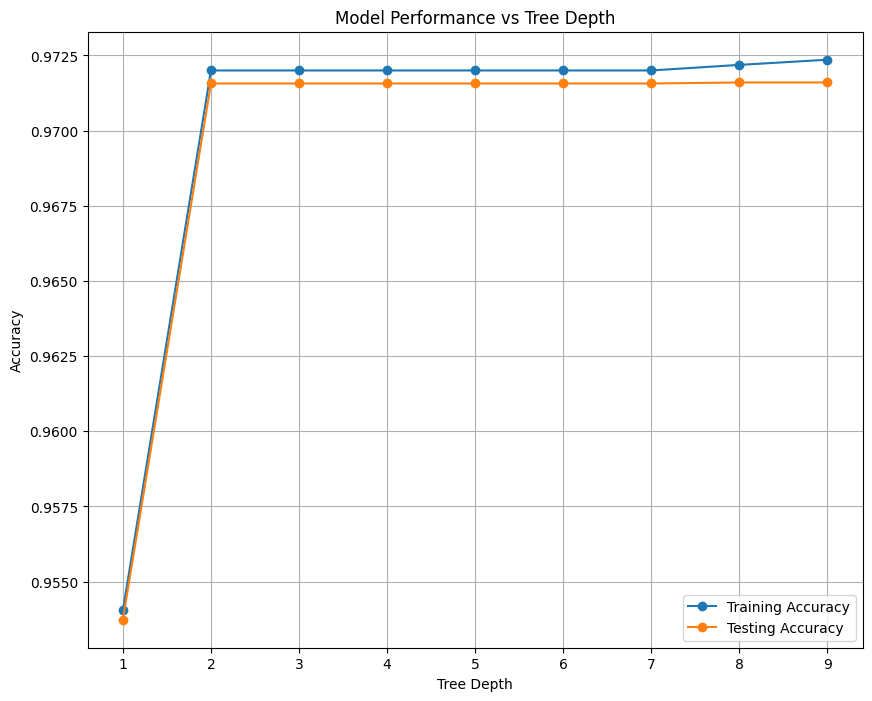

In [10]:
plt.figure(figsize=(10,8))
plt.plot(max_depths,
         train_scores,
         marker='o',
         label='Training Accuracy')
plt.plot(max_depths,
         test_scores,
         marker='o',
         label='Testing Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Model Performance vs Tree Depth')
plt.legend()
plt.grid(True)
plt.show()

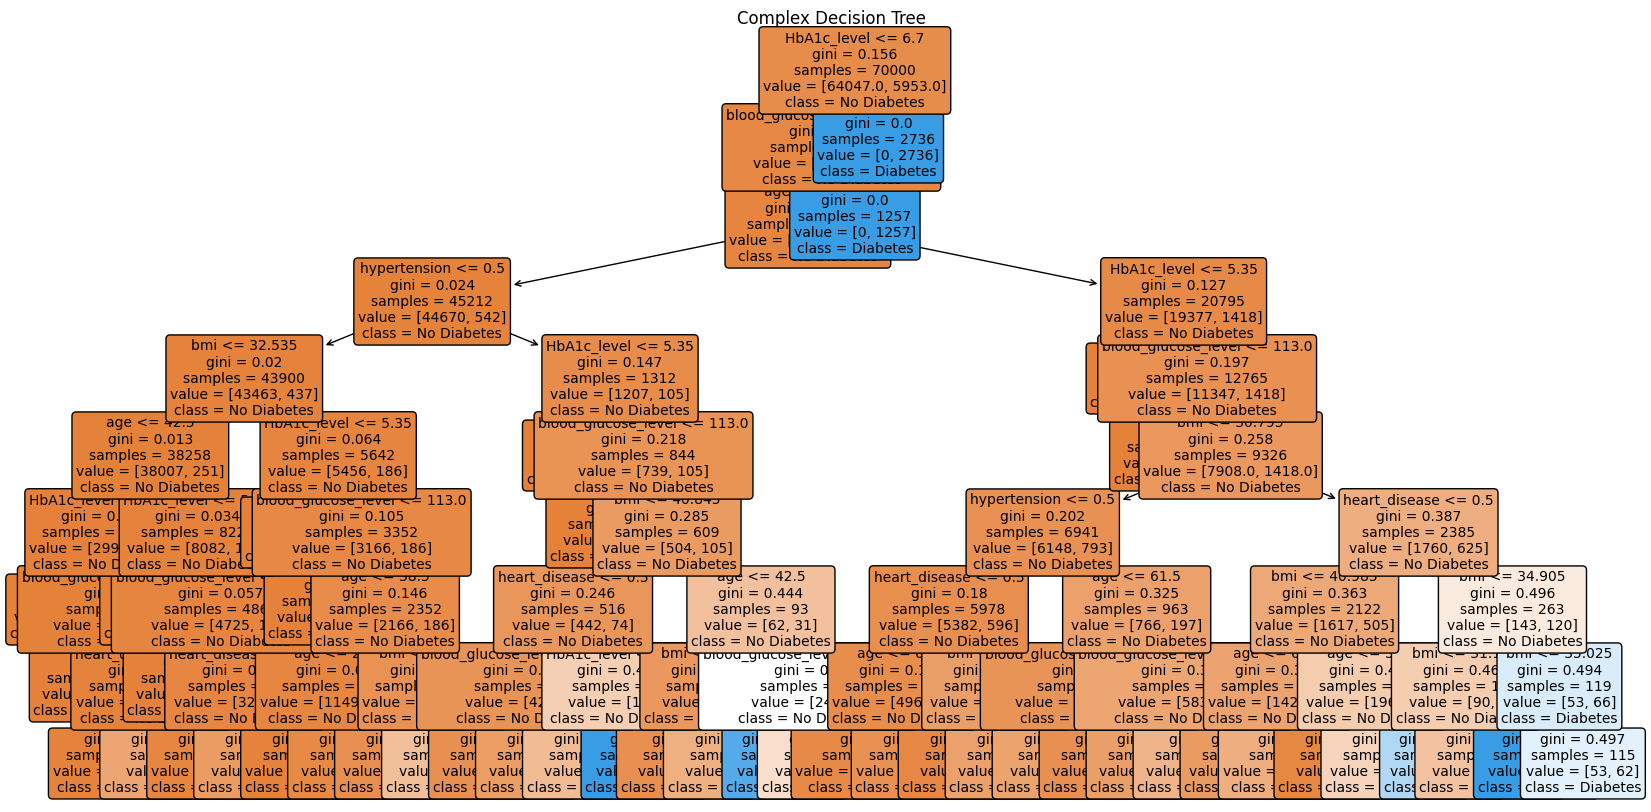

In [11]:
plt.figure(figsize=(20,10))
plot_tree(model,
          filled=True,
          feature_names=list(X.columns),
          class_names=['No Diabetes','Diabetes'],
          rounded=True,
         fontsize=10)
plt.title('Complex Decision Tree')
plt.show()

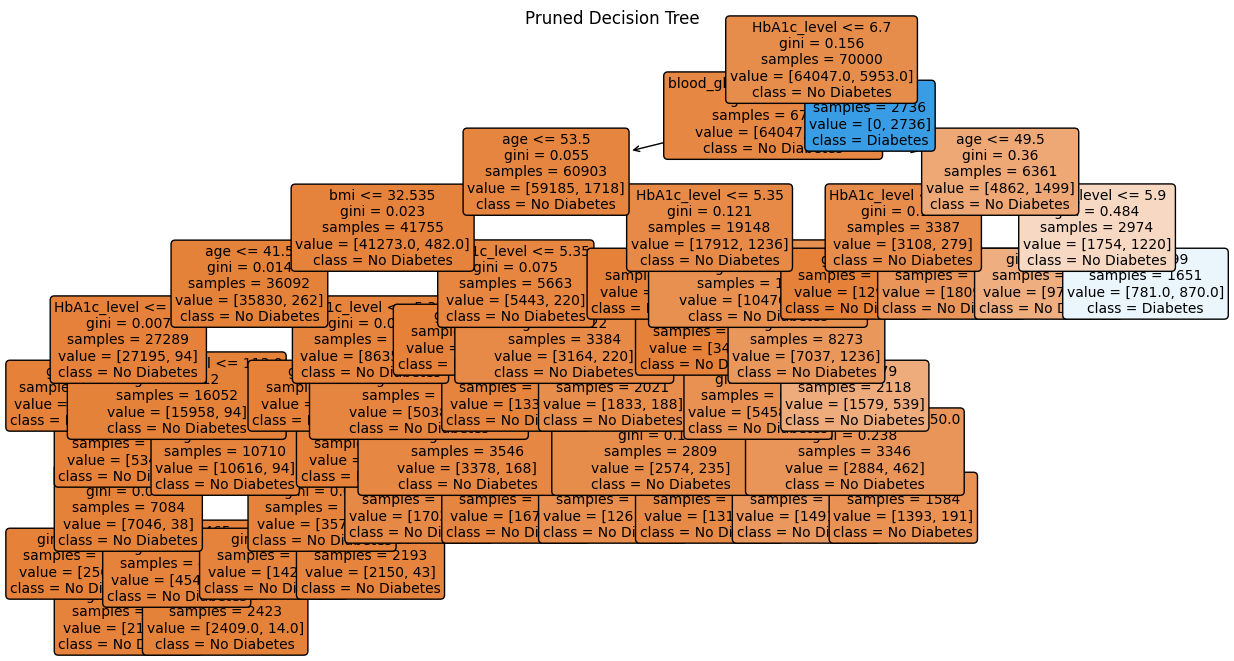

In [12]:
plt.figure(figsize=(15,8))
plot_tree(pruned_model,
          filled=True,
          feature_names=list(X.columns),
          class_names=['No Diabetes','Diabetes'],
          rounded=True,
          fontsize=10)
plt.title('Pruned Decision Tree')
plt.show()

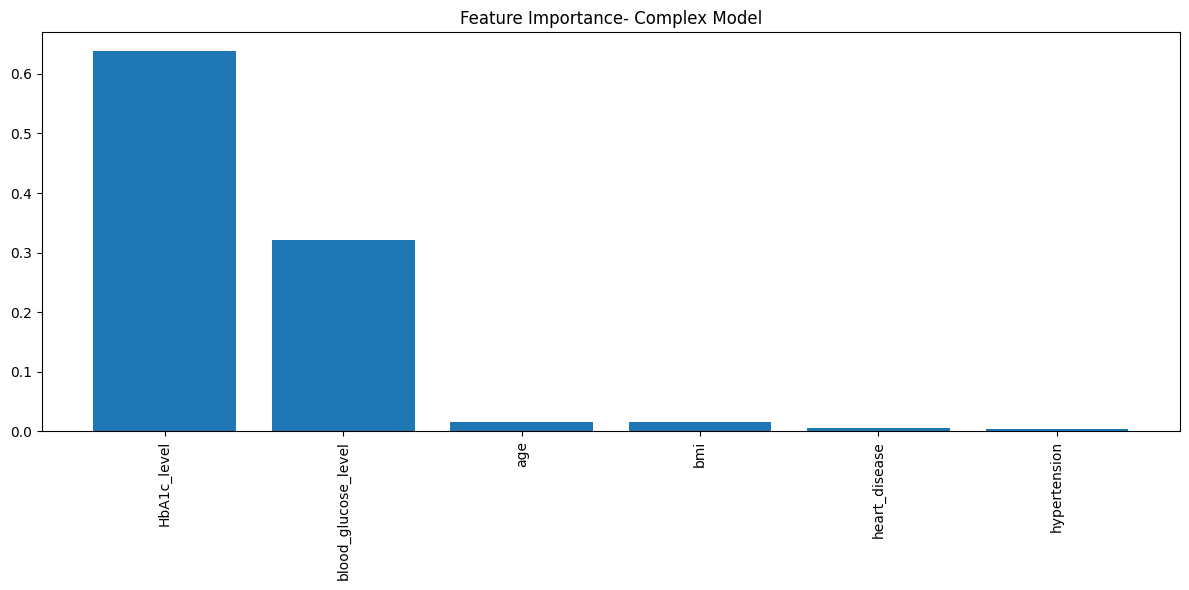

Top 5 features for Feature Importance- Complex Model:
HbA1c_level: 0.6379
blood_glucose_level: 0.3207
age: 0.0166
bmi: 0.0160
heart_disease: 0.0049


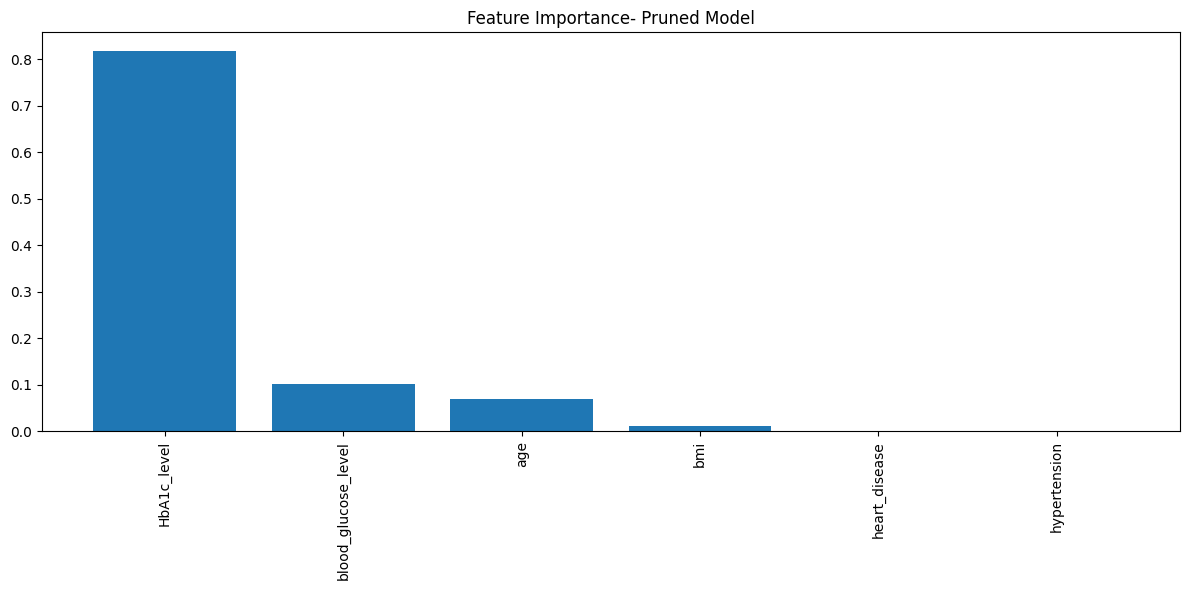

Top 5 features for Feature Importance- Pruned Model:
HbA1c_level: 0.8172
blood_glucose_level: 0.1014
age: 0.0696
bmi: 0.0119
heart_disease: 0.0000


In [13]:
def plot_feature_importance(model, feature_names, title):
    importances=model.feature_importances_
    indices=np.argsort(importances)[::-1]

    plt.figure(figsize=(12,6))
    plt.title(title)
    plt.bar(range(len(importances)), importances[indices], align='center')
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
    plt.tight_layout()
    plt.show()

    print(f'Top 5 features for {title}:')
    for i in range(5):
        if i < len(indices):
            print(f'{feature_names[indices[i]]}: {importances[indices[i]]:.4f}')

plot_feature_importance(model, list(X.columns), 'Feature Importance- Complex Model')
plot_feature_importance(pruned_model, list(X.columns), 'Feature Importance- Pruned Model') 

## Random Forests

A **random forest** is an ensemble method that combines multiple decision trees to improve predictive performance and reduce overfitting. It uses bagging (bootstrap aggregating) and feature randomness to create diverse trees. Each tree is trained on a random subset of the data and features. 

The final prediction is made by averaging (regression) or majority voting (classification) across all trees. The random forest model reduces variance compared to a single tree, with the prediction variance approximated as:
$$
\mathrm{Var}(\hat{f}) \approx \frac{1}{B}\mathrm{Var}(T_b)
$$

where B=no. of trees, Tb=individual tree's prediction

Both methods are interpretable, handle non-linear relationships, and are widely used in machine learning tasks.

In [14]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(
    n_estimators=100,
    random_state=42)

rf_model.fit(X_train, y_train)
print('Random Forest model has been trained!')

print('\nRandom Forest Parameters:')
print(f'No. of trees (n_estimators): {rf_model.n_estimators}')
print(f'Maximum depth of trees: {"None (unlimited)" if rf_model.max_depth is None else rf_model.max_depth}')
print(f'Minimum samples to split: {rf_model.min_samples_split}')
print(f'Minimum samples per leaf: {rf_model.min_samples_leaf}')
print(f'Bootstrap samples used: {rf_model.bootstrap}')

n_nodes=[]
max_depths=[]

for tree in rf_model.estimators_:
    n_nodes.append(tree.tree_.node_count)
    max_depths.append(tree.tree_.max_depth)

print(f'\nAverage no. of nodes in the trees: {np.mean(n_nodes):.1f}')
print(f'Average maximum depth of the trees: {np.mean(max_depths):.1f}')

Random Forest model has been trained!

Random Forest Parameters:
No. of trees (n_estimators): 100
Maximum depth of trees: None (unlimited)
Minimum samples to split: 2
Minimum samples per leaf: 1
Bootstrap samples used: True

Average no. of nodes in the trees: 5526.5
Average maximum depth of the trees: 31.6



Random Forest Accuracy: 0.97

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27453
           1       0.91      0.69      0.78      2547

    accuracy                           0.97     30000
   macro avg       0.94      0.84      0.88     30000
weighted avg       0.97      0.97      0.97     30000


Confusion Matrix:
[[27285   168]
 [  793  1754]]


<Figure size 1000x800 with 0 Axes>

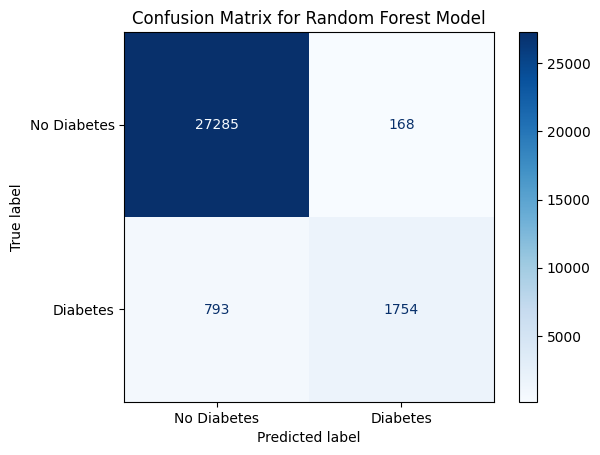


Prediction probabilities for the first 5 patients:
Patient 1: No Diabetes:0.9700, Diabetes:0.0300
Patient 2: No Diabetes:1.0000, Diabetes:0.0000
Patient 3: No Diabetes:1.0000, Diabetes:0.0000
Patient 4: No Diabetes:1.0000, Diabetes:0.0000
Patient 5: No Diabetes:0.9200, Diabetes:0.0800


In [15]:
y_pred=rf_model.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)
print(f'\nRandom Forest Accuracy: {accuracy:.2f}')
print('\nClassification Report:')
print(classification_report(y_test,y_pred))

conf_matrix=confusion_matrix(y_test,y_pred)
print('\nConfusion Matrix:')
print(conf_matrix)

plt.figure(figsize=(10,8))
cm_d=ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['No Diabetes','Diabetes'])
cm_d.plot(cmap='Blues')
plt.title('Confusion Matrix for Random Forest Model')
plt.grid(False)
plt.show()

y_proba=rf_model.predict_proba(X_test)
print('\nPrediction probabilities for the first 5 patients:')
for i in range(5):
    print(f'Patient {i+1}: No Diabetes:{y_proba[i][0]:.4f}, Diabetes:{y_proba[i][1]:.4f}')

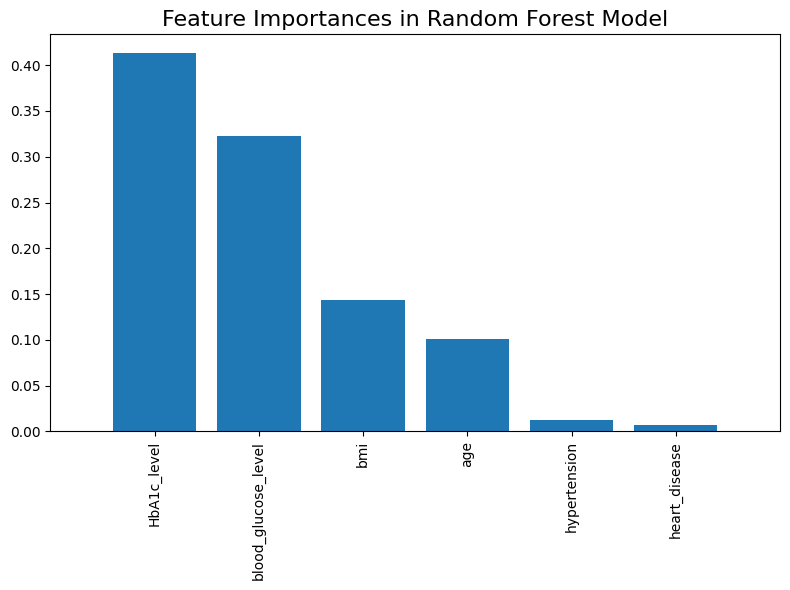


Top 5 most important features:
1. HbA1c_level: 0.4131
2. blood_glucose_level: 0.3222
3. bmi: 0.1441
4. age: 0.1008
5. hypertension: 0.0129


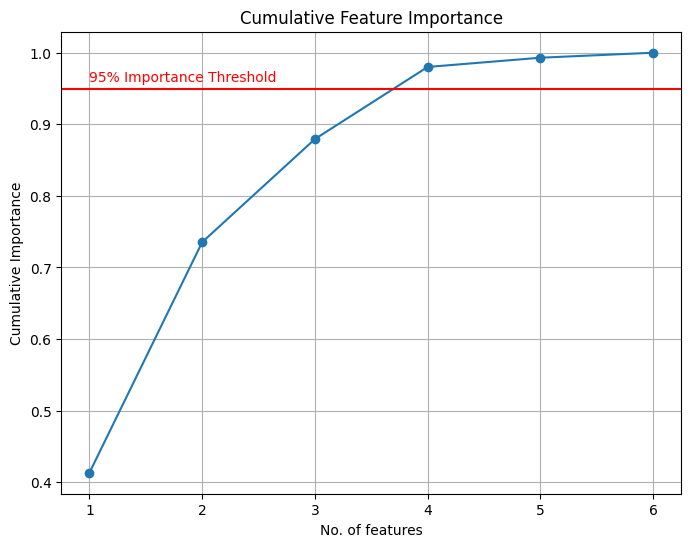

In [16]:
feature_importances=rf_model.feature_importances_

indices=np.argsort(feature_importances)[::-1]
names=[X.columns[i] for i in indices]

plt.figure(figsize=(8,6))
plt.title('Feature Importances in Random Forest Model',fontsize=16)
plt.bar(range(X.shape[1]),feature_importances[indices],align='center')
plt.xticks(range(X.shape[1]),names,rotation=90)
plt.xlim([-1,X.shape[1]])
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
for i in range(min(5,len(names))):
    print(f'{i+1}. {names[i]}: {feature_importances[indices[i]]:.4f}')

cumulative_importance=np.cumsum(feature_importances[indices])
plt.figure(figsize=(8,6))
plt.plot(range(1,len(cumulative_importance)+1), cumulative_importance, marker='o')
plt.xlabel('No. of features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(1,0.96,'95% Importance Threshold', color='red')
plt.grid(True)
plt.show()